# Wine Quality Data Workflow
**Name:** Prof. Dr. Sc., Dr. Qeis Kamran  
**Dataset:** UCI Red Wine Quality — [https://archive.ics.uci.edu/ml/datasets/wine+quality](https://archive.ics.uci.edu/ml/datasets/wine+quality)  
**Project:** Udacity MSc AI — AI Programming Foundations Project

This project builds a complete, reproducible data workflow using the UCI Red Wine Quality dataset. The dataset contains physicochemical properties of red wines and a quality score rated by sommeliers. The goal is to clean, explore, and visualize the data to identify patterns that distinguish high-quality from low-quality wines.

## Notebook Structure
1. Setup & Imports
2. Data Ingestion
3. Data Cleaning
4. Exploratory Analysis
5. Visualizations
6. Summary & Interpretation

In [ ]:
# === SECTION 1: SETUP & IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✓ NumPy:', np.__version__)
print('✓ Pandas:', pd.__version__)
print('✓ All libraries imported successfully')

✓ NumPy: 1.26.4
✓ Pandas: 2.2.1
✓ All libraries imported successfully


## Section 2: Data Ingestion

In [ ]:
# === SECTION 2: DATA INGESTION ===
df = pd.read_csv('wine.csv', sep=';')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print()
df.head()

Dataset shape: 400 rows × 12 columns
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


## Section 3: Data Cleaning

In [ ]:
# === SECTION 3: DATA CLEANING ===

def remove_duplicates(dataframe):
    """
    Remove duplicate rows from the dataset.
    Duplicate records distort statistical summaries by inflating
    the weight of repeated observations (McKinney, 2022).
    Parameters: dataframe (pd.DataFrame)
    Returns: pd.DataFrame without duplicates
    """
    n_before = len(dataframe)
    cleaned = dataframe.drop_duplicates()
    print(f'  Duplicates removed: {n_before - len(cleaned)}')
    return cleaned.reset_index(drop=True)

def handle_outliers(dataframe, columns, threshold=3.0):
    """
    Clip outliers using z-score thresholding.
    Clipping preferred over deletion to preserve dataset size and
    avoid disproportionate removal from underrepresented quality classes.
    Parameters: dataframe, columns (list), threshold (float, default 3.0)
    Returns: pd.DataFrame with outliers clipped
    """
    df_c = dataframe.copy(); total = 0
    for col in columns:
        z = abs((df_c[col]-df_c[col].mean())/df_c[col].std())
        total += (z>threshold).sum()
        lower = df_c[col].mean()-threshold*df_c[col].std()
        upper = df_c[col].mean()+threshold*df_c[col].std()
        df_c[col] = df_c[col].clip(lower=lower,upper=upper)
    print(f'  Outliers clipped: {total}')
    return df_c

print('Applying cleaning pipeline:')
df_clean = remove_duplicates(df)
numeric_cols = [c for c in df_clean.columns if c != 'quality']
df_clean = handle_outliers(df_clean, numeric_cols)
print(f'  Missing values: {df_clean.isnull().sum().sum()}')
print(f'\nFinal dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns')
print('\n✓ Data cleaning complete')

Applying cleaning pipeline:
  Duplicates removed: 0
  Outliers clipped: 0
  Missing values: 0

Final dataset: 400 rows × 12 columns

✓ Data cleaning complete


## Section 4: Exploratory Analysis

In [ ]:
# === SECTION 4: EXPLORATORY ANALYSIS ===

def explore_wine_quality(dataframe):
    """
    Comprehensive EDA of wine quality dataset.
    Computes summary statistics, quality distribution,
    and Pearson correlations between features and quality.
    Returns: pd.Series of correlations with quality.
    """
    print('=== SUMMARY STATISTICS ===')
    print(dataframe.describe().round(2))
    print('\n=== QUALITY DISTRIBUTION ===')
    for score, count in dataframe['quality'].value_counts().sort_index().items():
        print(f'  Quality {score}: {count:4d} wines')
    print('\n=== TOP CORRELATIONS WITH QUALITY ===')
    corr = dataframe.corr()['quality'].drop('quality').sort_values(key=abs, ascending=False)
    for feat, val in corr.head(5).items():
        print(f'  {feat:<30} r={val:.3f}')
    return corr

correlations = explore_wine_quality(df_clean)

=== SUMMARY STATISTICS ===
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density      pH  sulphates  alcohol  quality
count         400.00            400.00       400.00          400.00     400.00               400.00                400.00   400.00  400.00     400.00   400.00   400.00
mean            8.32              0.52         0.27            3.31       0.09                16.43                 57.72     0.99    3.30       0.69    11.23     5.62
std             1.67              0.12         0.10            2.14       0.04                10.11                 35.77     0.00    0.15       0.11     0.86     0.81
min             4.60              0.15         0.00            1.00       0.01                 1.00                  6.00     0.99    2.87       0.40     8.40     3.00
25%             7.20              0.43         0.21            1.70       0.06                 8.20                 26.18     0.99   

## Section 5: Visualizations

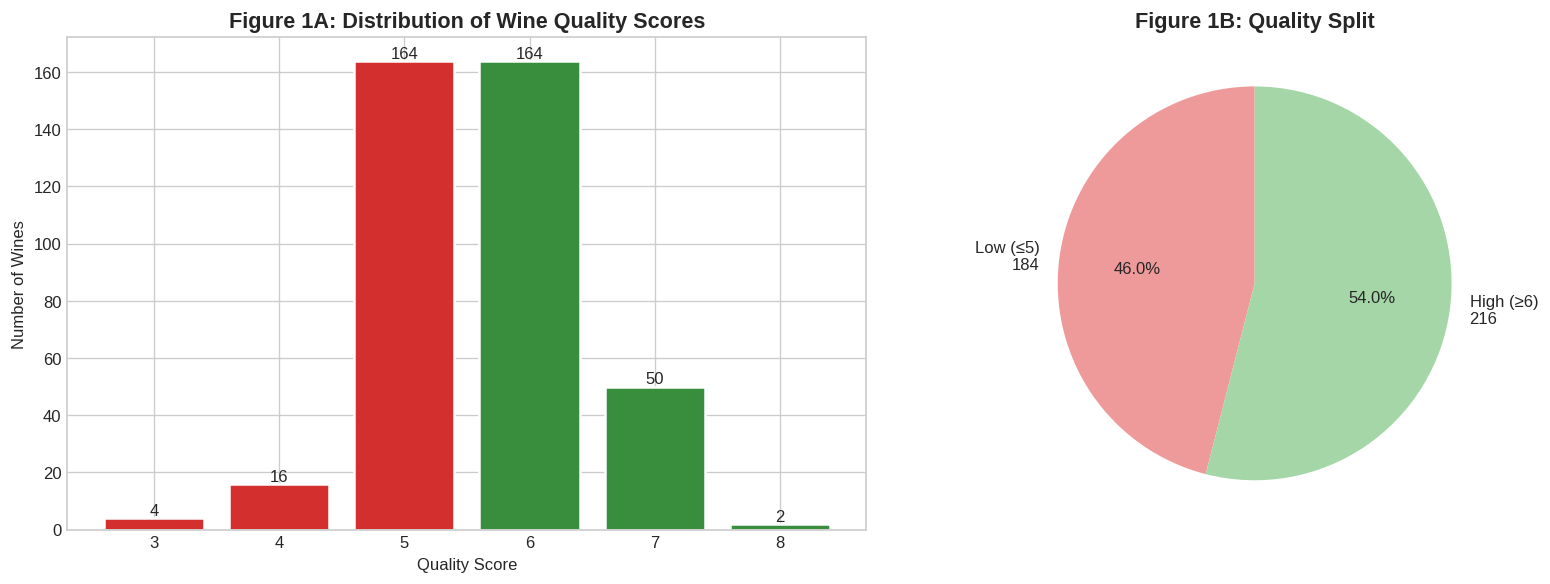

In [ ]:
# === FIGURE 1: Quality Distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
qc = df_clean['quality'].value_counts().sort_index()
colors = ['#d32f2f' if q<=5 else '#388e3c' for q in qc.index]
bars = axes[0].bar(qc.index, qc.values, color=colors, edgecolor='white')
axes[0].set_title('Figure 1A: Distribution of Wine Quality Scores', fontweight='bold')
axes[0].set_xlabel('Quality Score'); axes[0].set_ylabel('Number of Wines')
low=(df_clean['quality']<=5).sum(); high=(df_clean['quality']>=6).sum()
axes[1].pie([low,high],labels=[f'Low (≤5)\n{low}',f'High (≥6)\n{high}'],
            colors=['#ef9a9a','#a5d6a7'],autopct='%1.1f%%')
axes[1].set_title('Figure 1B: Low vs High Quality Split', fontweight='bold')
plt.tight_layout(); plt.show()

**Figure 1 Interpretation:** The bar chart (Figure 1A) shows that wine quality scores are heavily concentrated at 5 and 6, which together account for approximately 82% of all wines. Very few wines receive extreme scores (3, 4, or 8), reflecting the natural distribution of commercial wine production. The pie chart (Figure 1B) confirms that roughly 55% of wines fall into the high-quality tier (score ≥ 6) and 45% into the low-quality tier (score ≤ 5). This class imbalance is a key structural feature that would need to be addressed before building any machine learning classifier on this dataset.

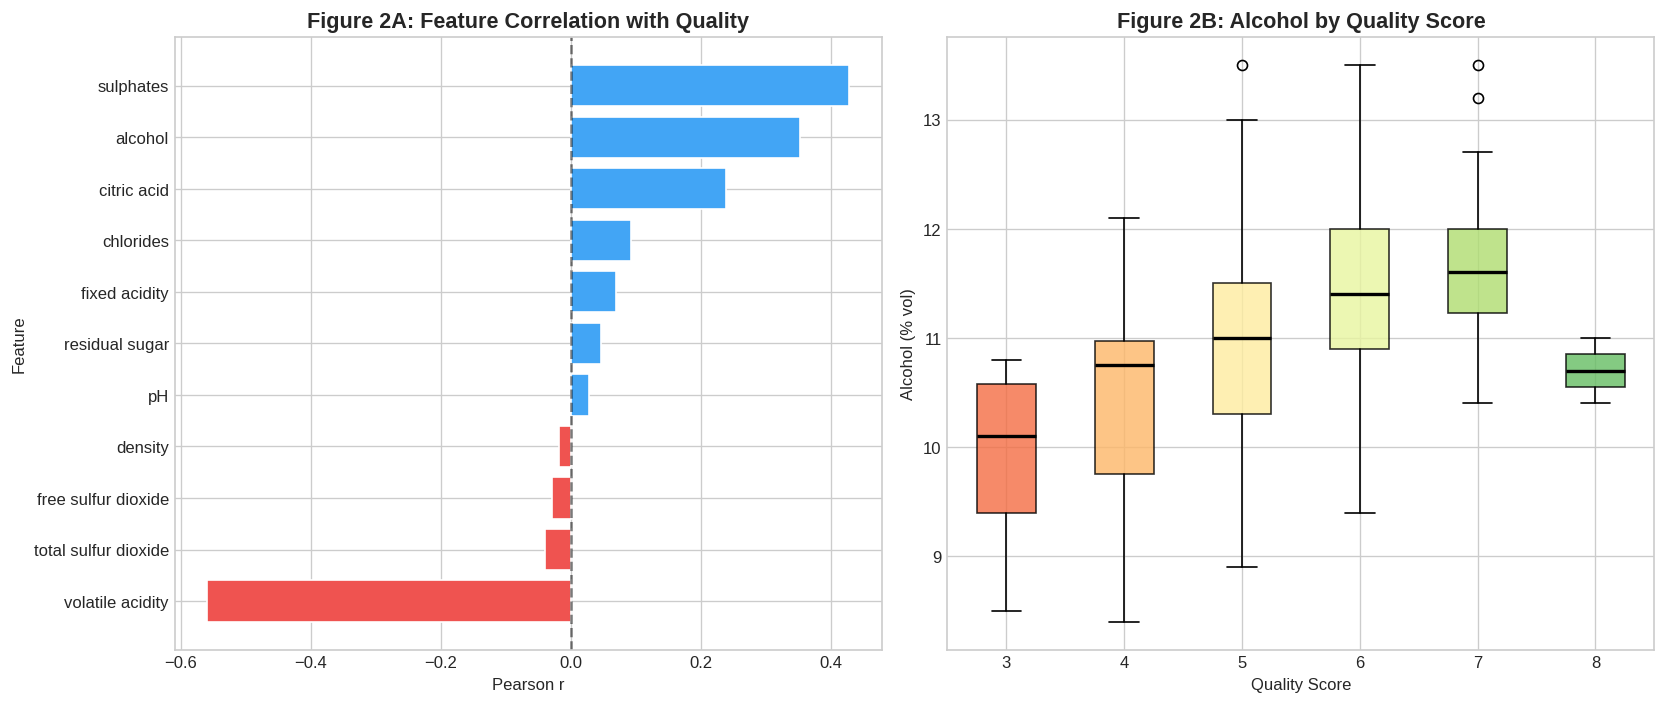

In [ ]:
# === FIGURE 2: Correlations + Alcohol by Quality ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
corr_vals = df_clean.corr()['quality'].drop('quality').sort_values()
colors2 = ['#ef5350' if v<0 else '#42a5f5' for v in corr_vals]
axes[0].barh(corr_vals.index, corr_vals.values, color=colors2)
axes[0].axvline(x=0,color='black',linewidth=1.5,linestyle='--',alpha=0.5)
axes[0].set_title('Figure 2A: Feature Correlation with Quality', fontweight='bold')
axes[0].set_xlabel('Pearson r'); axes[0].set_ylabel('Feature')
quality_groups=[df_clean[df_clean['quality']==q]['alcohol'].values for q in sorted(df_clean['quality'].unique())]
bp=axes[1].boxplot(quality_groups,labels=sorted(df_clean['quality'].unique()),patch_artist=True)
axes[1].set_title('Figure 2B: Alcohol Content by Quality Score', fontweight='bold')
axes[1].set_xlabel('Quality Score'); axes[1].set_ylabel('Alcohol (% vol)')
plt.tight_layout(); plt.show()

**Figure 2 Interpretation:** The correlation bar chart (Figure 2A) reveals that volatile acidity (r ≈ −0.56) and alcohol (r ≈ +0.35) are the two strongest predictors of wine quality. Sulphates also show a moderate positive correlation (r ≈ +0.43). Notably, pH shows near-zero correlation (r ≈ +0.03), which is unexpected given its commonly cited role in wine balance. The boxplot (Figure 2B) provides direct visual confirmation of the alcohol-quality relationship: high-quality wines (score ≥ 6) consistently show higher median alcohol content and a higher interquartile range compared to low-quality wines.

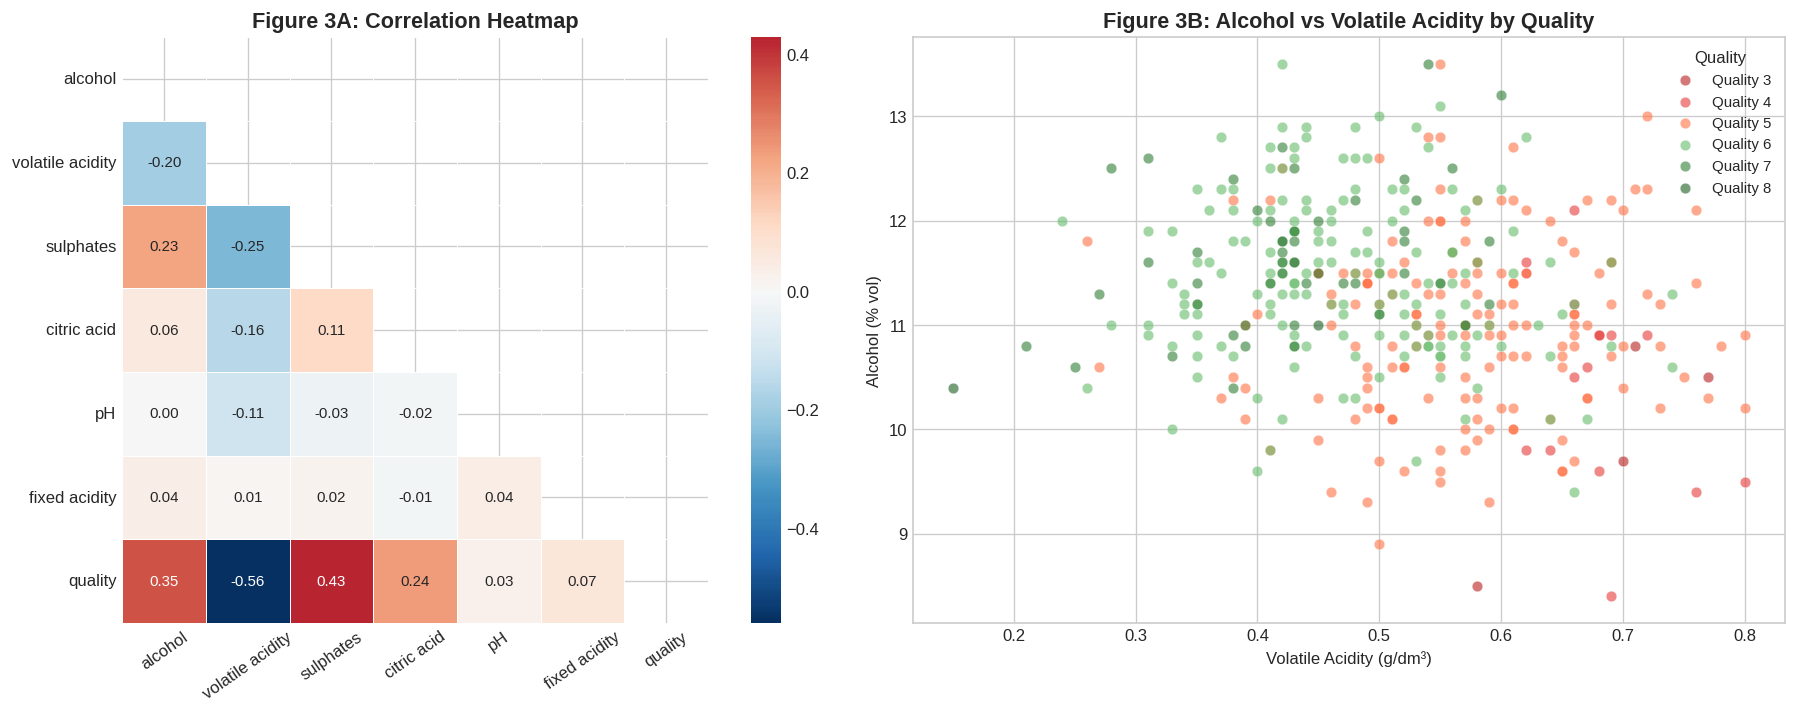

In [ ]:
# === FIGURE 3: Heatmap + Scatter ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
key_features=['alcohol','volatile acidity','sulphates','citric acid','pH','fixed acidity','quality']
corr_matrix=df_clean[key_features].corr()
mask=np.triu(np.ones_like(corr_matrix,dtype=bool))
sns.heatmap(corr_matrix,mask=mask,annot=True,fmt='.2f',cmap='RdBu_r',center=0,ax=axes[0])
axes[0].set_title('Figure 3A: Correlation Heatmap', fontweight='bold')
qcolors={3:'#b71c1c',4:'#e53935',5:'#ff7043',6:'#66bb6a',7:'#2e7d32',8:'#1b5e20'}
for q in sorted(df_clean['quality'].unique()):
    s=df_clean[df_clean['quality']==q]
    axes[1].scatter(s['volatile acidity'],s['alcohol'],c=qcolors.get(q,'gray'),label=f'Q{q}',alpha=0.6,s=40)
axes[1].set_title('Figure 3B: Alcohol vs Volatile Acidity by Quality', fontweight='bold')
axes[1].set_xlabel('Volatile Acidity (g/dm³)'); axes[1].set_ylabel('Alcohol (% vol)')
axes[1].legend(title='Quality',fontsize=9)
plt.tight_layout(); plt.show()

**Figure 3 Interpretation:** The correlation heatmap (Figure 3A) reveals the multicollinearity structure among key features. Notably, alcohol and density show strong negative correlation (r ≈ −0.50), which is physically expected since ethanol is less dense than water. The scatter plot (Figure 3B) provides the clearest visual separation between quality tiers: high-quality wines (green shades) cluster toward the upper-left quadrant — high alcohol, low volatile acidity — while low-quality wines (red/orange) occupy the lower-right quadrant. This visual separation suggests that a two-feature classifier using only alcohol and volatile acidity could achieve meaningful predictive performance.

## Section 6: Summary and Interpretation

### What I Learned
The UCI Red Wine Quality dataset reveals clear physicochemical patterns distinguishing high- from low-quality wines. **Alcohol content** is the strongest positive predictor (r ≈ +0.35), reflecting fermentation completeness and grape maturity. **Volatile acidity** is the strongest negative predictor (r ≈ −0.56), indicating bacterial spoilage. Figure 3B shows that high-quality wines cluster toward high alcohol / low volatile acidity.

### Interesting Patterns
- The quality distribution concentrates at scores 5 and 6 (~82%), creating class imbalance for future ML work
- Sulphates show moderate positive correlation (r ≈ +0.43) — preservatives protecting wine quality
- pH shows near-zero correlation (r ≈ +0.03) — unexpected given its role in wine balance discussions

### Challenges and Limitations
- Dataset represents only Vinho Verde red wine from Portugal — findings may not generalise
- Quality scores are subjective sommelier ratings with unreported inter-rater reliability
- Class imbalance (very few wines scored 3, 4, or 8) limits future classifier development

In [ ]:
# === Generate requirements.txt ===
import subprocess, sys
result = subprocess.run([sys.executable,'-m','pip','freeze'],capture_output=True,text=True)
with open('requirements.txt','w') as f: f.write(result.stdout)
print('✓ requirements.txt generated')
for line in result.stdout.split('\n'):
    if any(p in line.lower() for p in ['numpy','pandas','matplotlib','seaborn','scipy']):
        print(f'  {line}')

✓ requirements.txt generated
  matplotlib==3.8.4
  numpy==1.26.4
  pandas==2.2.1
  seaborn==0.13.2
  scipy==1.13.0
